## Visualización del campo de densidad de materia

En esta sección leeremos la distribución de partículas desde un snapshot de simulación almacenado en **formato Gadget**. El snapshot contiene, entre otras cantidades, las posiciones y velocidades de las partículas de la simulación.

La distribución de partículas es discreta. Para obtener un campo de densidad continuo, asignaremos las partículas a una malla tridimensional regular utilizando el esquema de asignación de masa **Cloud-In-Cell (CIC)**.

A partir de este campo definimos el contraste de densidad como

$$
\delta(\mathbf{x}) = \frac{\rho(\mathbf{x})-\bar{\rho}}{\bar{\rho}}
= \frac{\rho(\mathbf{x})}{\bar{\rho}} - 1,
$$

donde $\rho(\mathbf{x})$ es la densidad local de materia y $\bar{\rho}$ es la densidad media de materia de la simulación.

Por lo tanto,

$$
1+\delta(\mathbf{x}) = \frac{\rho(\mathbf{x})}{\bar{\rho}}.
$$

Esta cantidad permite interpretar fácilmente el campo de densidad:

- $1+\delta = 1$: densidad media,
- $1+\delta > 1$: regiones sobredensas,
- $1+\delta < 1$: regiones subdensas.

### 1. Proyección del campo de densidad

Primero visualizaremos la distribución de materia a gran escala mediante una proyección del campo tridimensional sobre un plano bidimensional.

Por ejemplo, una proyección a lo largo de la dirección $X$ produce un mapa de densidad en el plano $YZ$. Para ello promediamos los valores de $1+\delta$ a lo largo de $X$,

$$
\Sigma(Y,Z) = \frac{1}{N_x}\sum_{i=1}^{N_x}
\left[1+\delta(X_i,Y,Z)\right].
$$

Esta proyección combina estructuras localizadas en diferentes posiciones a lo largo de la dirección $X$ y permite visualizar la red cósmica sobre todo el volumen de la simulación.

### 2. Slice del campo de densidad y distribución de partículas

Una proyección contiene información proveniente de muchas posiciones distintas a lo largo de la línea de visión. Para estudiar el campo de densidad de manera más local, podemos seleccionar un único **slice** de la simulación.

Para un índice de malla $i_x$, el slice de densidad correspondiente es

$$
1+\delta(X_{i_x},Y,Z).
$$

Podemos comparar directamente este mapa bidimensional con las partículas localizadas dentro del mismo intervalo espacial,

$$
X_{i_x} \leq X < X_{i_x}+\Delta x,
$$

donde el tamaño de un voxel es

$$
\Delta x = \frac{L_{\rm box}}{N_{\rm grid}}.
$$

Ambas figuras representan la misma región física de dos formas distintas:

- el mapa de densidad muestra el campo continuo obtenido después de asignar las partículas a la malla;
- el gráfico de partículas muestra la distribución discreta original de las partículas.

Esta comparación permite visualizar cómo la distribución de partículas se transforma en un campo continuo mediante el esquema de asignación de masa.

### 3. Distorsiones en espacio de redshift

Las posiciones observadas de las galaxias se infieren a partir de sus redshifts y no directamente de sus distancias comóviles reales. Por esta razón, las velocidades peculiares producen un desplazamiento adicional a lo largo de la línea de visión, generando las llamadas **distorsiones en espacio de redshift (RSD)**.

Si la línea de visión se escoge a lo largo de uno de los ejes coordenados, la posición de cada partícula en esa dirección se modifica de acuerdo con su velocidad peculiar. Esquemáticamente,

$$
s_{\parallel}
=
x_{\parallel}
+
\frac{v_{\parallel}}{aH},
$$

donde $x_{\parallel}$ es la posición en espacio real, $v_{\parallel}$ es la velocidad peculiar a lo largo de la línea de visión, $a$ es el factor de escala y $H$ es el parámetro de Hubble al redshift correspondiente.

Después de mover las partículas a espacio de redshift, construiremos nuevamente el campo de densidad usando el mismo procedimiento CIC y lo compararemos con el campo en espacio real.

Para esta comparación, en lugar de mostrar una sola capa de la malla, promediaremos varias capas vecinas con el objetivo de obtener una visualización más clara. Por ejemplo, al promediar cinco celdas consecutivas obtenemos

$$
1+\delta_{\rm slab}(Y,Z)
=
\frac{1}{5}
\sum_{i=1}^{5}
\left[1+\delta(X_i,Y,Z)\right].
$$

Para una caja de $512\,h^{-1}{\rm Mpc}$ y una malla de densidad de $512^3$, el tamaño de un voxel es aproximadamente

$$
\Delta x = \frac{512}{512}
= 1.\,h^{-1}{\rm Mpc}.
$$

Por lo tanto, cinco capas corresponden a una región de aproximadamente

$$
2\Delta x = 2\,h^{-1}{\rm Mpc}
$$

de espesor.

Promediar varias capas reduce la apariencia discreta del campo y permite identificar con mayor claridad las diferencias entre el **espacio real** y el **espacio de redshift**.

**Tutorial basado en tutorial de Pylians**: https://quijote-simulations.readthedocs.io/en/latest/tutorials.html

In [1]:
import numpy as np
import readgadget
import MAS_library as MASL
import matplotlib.pyplot as plt

In [2]:
#ls ../../codes/l-picola/snapshots/test_z0p000*

In [3]:
snapshot = '../../codes/l-picola/snapshots/test_z0p000'
grid     = 512    #the density field will have grid^3 voxels
MAS      = 'CIC'  #Mass-assignment scheme:'NGP', 'CIC', 'TSC', 'PCS'
verbose  = True   #whether to print information about the progress
ptype    = [1]    #[1](CDM)

In [4]:
# read header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize  #Mpc/h
redshift = header.redshift     #redshift of the snapshot
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h

# read positions, velocities and IDs of the particles
pos = readgadget.read_block(snapshot, "POS ", ptype) #positions in Mpc/h

In [5]:
#Get the minimum and maximum values for x, y and z
print('Redshift: %.3f'%redshift)
print('%.3f < X < %.3f'%(np.min(pos[:,0]), np.max(pos[:,0])))
print('%.3f < Y < %.3f'%(np.min(pos[:,1]), np.max(pos[:,1])))
print('%.3f < Z < %.3f'%(np.min(pos[:,2]), np.max(pos[:,2])))

Redshift: 0.000
0.000 < X < 512.000
0.000 < Y < 512.000
0.000 < Z < 512.000


In [6]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)

Construct the 3D contrast density field

In [7]:
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)


Using CIC mass assignment scheme
Time taken = 0.615 seconds



In [8]:
# Convert particle-count field into contrast density
delta /= np.mean(delta, dtype=np.float64)
delta -= 1.0

In [9]:
# Projection along the complete X direction into the YZ plane
density_projection = np.mean(delta + 1, axis=0)
print(density_projection.min(), density_projection.max())

0.25435165 7.3217483


In [10]:
vmin, vmax= density_projection.min(), density_projection.max()

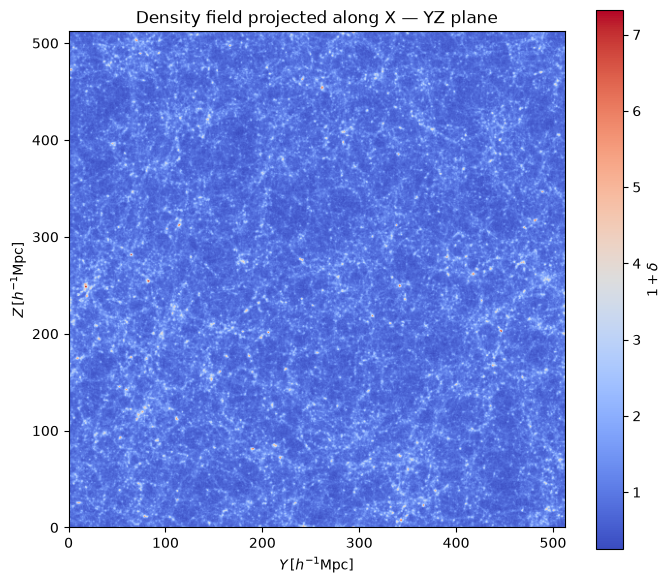

In [11]:
fig, ax = plt.subplots(figsize=(8,7))

im = ax.imshow(density_projection.T, cmap='coolwarm', origin='lower',
               #vmin=1e10, vmax=4e11, 
               vmin=vmin, vmax=vmax, #vmin, vmax valores extremos del mapa de color
               extent=[0,BoxSize,0,BoxSize])

ax.set_title('Density field projected along X — YZ plane')
ax.set_xlabel(r'$Y\,[h^{-1}{\rm Mpc}]$')
ax.set_ylabel(r'$Z\,[h^{-1}{\rm Mpc}]$')
ax.set_aspect('equal')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$1+\delta$')

plt.show()

Slice: 256.000 < X < 257.000 Mpc/h
Number of particles: 31211


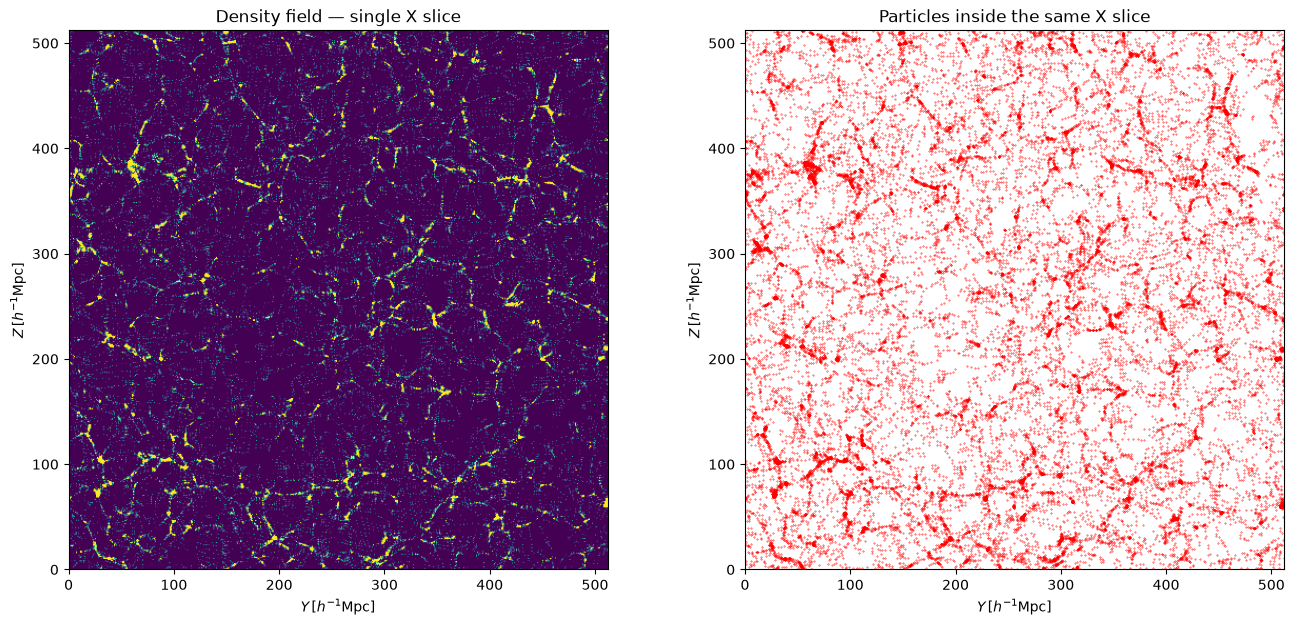

In [13]:
# Width of one voxel
dx = BoxSize/grid
ix = 256
density_slice = delta[ix,:,:]
# Physical limits of the density slice
x_min = ix*dx
x_max = (ix+1)*dx

# Particles inside the same spatial slice
indexes = np.where((pos[:,0] >= x_min) & (pos[:,0] < x_max))
pos_slice = pos[indexes]

print('Slice: %.3f < X < %.3f Mpc/h' % (x_min, x_max))
print('Number of particles:', len(pos_slice))

fig, ax = plt.subplots(1, 2, figsize=(16,7))

im = ax[0].imshow(density_slice.T, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', extent=[0,BoxSize,0,BoxSize])
ax[1].scatter(pos_slice[:,1], pos_slice[:,2], s=0.1, c='r')

ax[0].set_title(r'Density field — single X slice')
ax[1].set_title(r'Particles inside the same X slice')

ax[0].set_xlabel(r'$Y\,[h^{-1}{\rm Mpc}]$'); ax[0].set_ylabel(r'$Z\,[h^{-1}{\rm Mpc}]$')
ax[1].set_xlabel(r'$Y\,[h^{-1}{\rm Mpc}]$'); ax[1].set_ylabel(r'$Z\,[h^{-1}{\rm Mpc}]$')

ax[0].set_xlim(0,BoxSize); ax[0].set_ylim(0,BoxSize)
ax[1].set_xlim(0,BoxSize); ax[1].set_ylim(0,BoxSize)

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

#cbar = fig.colorbar(im, ax=ax[0], shrink=0.9)
#cbar.set_label(r'$1+\delta$')

plt.show()

Lets now compute density fields in redshift-space

In [14]:
import redshift_space_library as RSL
import numpy as np
import readgadget
import MAS_library as MASL

snapshot = '../../codes/l-picola/snapshots/test_z0p000'
grid     = 512    #the density field will have grid^3 voxels
MAS      = 'CIC'  #Mass-assignment scheme:'NGP', 'CIC', 'TSC', 'PCS'
verbose  = True   #whether to print information about the progress

Lets read the header and the particle positions and masses 

In [15]:
# read header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize  #Mpc/h
Nall     = header.nall         #Total number of particles
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
Omega_l  = header.omega_l      #value of Omega_l
h        = header.hubble       #value of h
redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)

# read positions and velocities of the particles
pos_r = readgadget.read_block(snapshot, "POS ", [1]) #positions in Mpc/h
vel = readgadget.read_block(snapshot, "VEL ", [1])     #velocities in km/s

Print some information about the data read

In [16]:
print('BoxSize = %.3f Mpc/h'%BoxSize)
print('Rdshift = %.3f'%redshift)
print('Mass DM = %.3e'%Masses[1])
print('%.3f < X_DM < %.3f'%(np.min(pos_r[:,0]), np.max(pos_r[:,0])))
print('%.3f < Y_DM < %.3f'%(np.min(pos_r[:,1]), np.max(pos_r[:,1])))
print('%.3f < Z_DM < %.3f'%(np.min(pos_r[:,2]), np.max(pos_r[:,2])))

BoxSize = 512.000 Mpc/h
Rdshift = 0.000
Mass DM = 6.883e+11
0.000 < X_DM < 512.000
0.000 < Y_DM < 512.000
0.000 < Z_DM < 512.000


Now lets move particles to redshift space along the X-axis

In [17]:
# Real-space positions remain unchanged
pos_rsd = pos_r.copy()

In [18]:
# move dark matter particles to redshift-space
axis     = 2      #axis along which to move particles to redshift-space (0-X), (1-Y), (2-Z)
RSL.pos_redshift_space(pos_rsd, vel, BoxSize, Hubble, redshift, axis)

**Exercicio de calentamiento: Mover las partículas al espacio de redshift y graficar 
sin utilizar RSL.pos_redshift_space para z=0.5**


Now construct the density field of matter (DM)

In [19]:
# define the matrix holding the density field
delta_r = np.zeros((grid,grid,grid), dtype=np.float32)
delta_rsd = np.zeros((grid,grid,grid), dtype=np.float32)

# define two arrays with the masses of the DM particles
mass_r = np.ones(pos_r.shape[0], dtype=np.float32)*float(Masses[1])
mass_rsd = np.ones(pos_rsd.shape[0], dtype=np.float32)*float(Masses[1])

# construct the density field
MASL.MA(pos_r, delta_r, BoxSize, MAS, W=mass_r, verbose=verbose)
MASL.MA(pos_rsd, delta_rsd, BoxSize, MAS, W=mass_rsd, verbose=verbose)


Using CIC mass assignment scheme with weights
Time taken = 0.905 seconds


Using CIC mass assignment scheme with weights
Time taken = 0.857 seconds



The overdensity field:

In [20]:
delta_r /= np.mean(delta_r, dtype=np.float64);  delta_r -= 1.0
delta_rsd /= np.mean(delta_rsd, dtype=np.float64);  delta_rsd -= 1.0
print('%.3f < delta_r < %.3f'%(np.min(delta_r), np.max(delta_r)))
print('%.3f < delta_rsd < %.3f'%(np.min(delta_rsd), np.max(delta_rsd)))
print('<delta_r> = %.3f'%np.mean(delta_r))
print('<delta_rsd> = %.3f'%np.mean(delta_rsd))

-1.000 < delta_r < 1435.551
-1.000 < delta_rsd < 488.800
<delta_r> = 0.000
<delta_rsd> = 0.000


Lets plot the density field along three different projections to see the effect of the redshift-space distortions

**Plane XY**

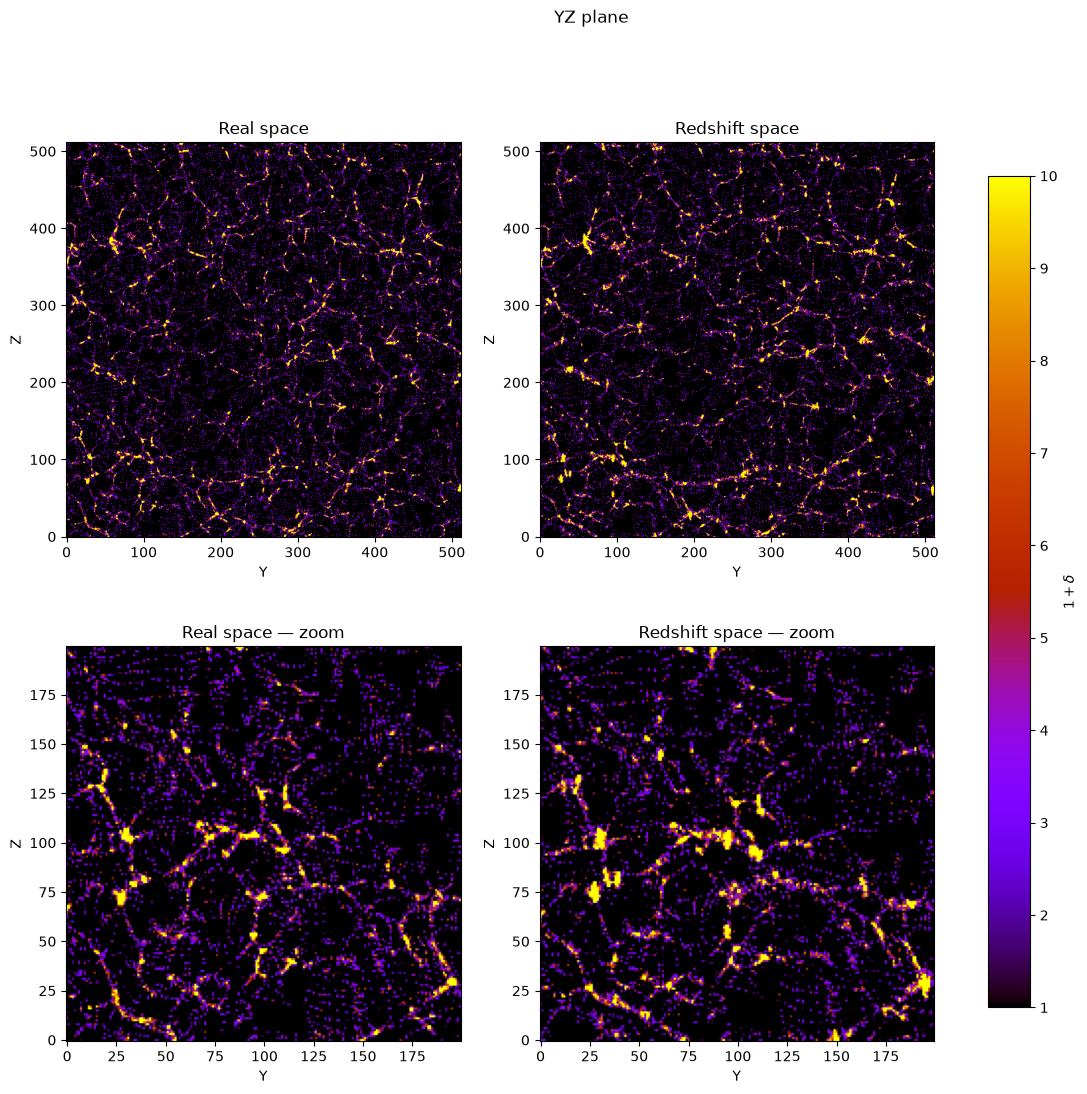

In [21]:
ix = grid//2

df_x_r = delta_r[ix,:,:] + 1
df_x_rsd = delta_rsd[ix,:,:] + 1

fig, ax = plt.subplots(2, 2, figsize=(14,12))

im = ax[0,0].imshow(df_x_r.T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')
ax[0,1].imshow(df_x_rsd.T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')

ax[1,0].imshow(df_x_r[:200,:200].T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')
ax[1,1].imshow(df_x_rsd[:200,:200].T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')

ax[0,0].set_title('Real space')
ax[0,1].set_title('Redshift space')
ax[1,0].set_title('Real space — zoom')
ax[1,1].set_title('Redshift space — zoom')

ax[0,0].set_xlabel('Y'); ax[0,0].set_ylabel('Z')
ax[0,1].set_xlabel('Y'); ax[0,1].set_ylabel('Z')
ax[1,0].set_xlabel('Y'); ax[1,0].set_ylabel('Z')
ax[1,1].set_xlabel('Y'); ax[1,1].set_ylabel('Z')

cbar = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.9)
cbar.set_label(r'$1+\delta$')

fig.suptitle('YZ plane')
plt.show()

**Plane XY**

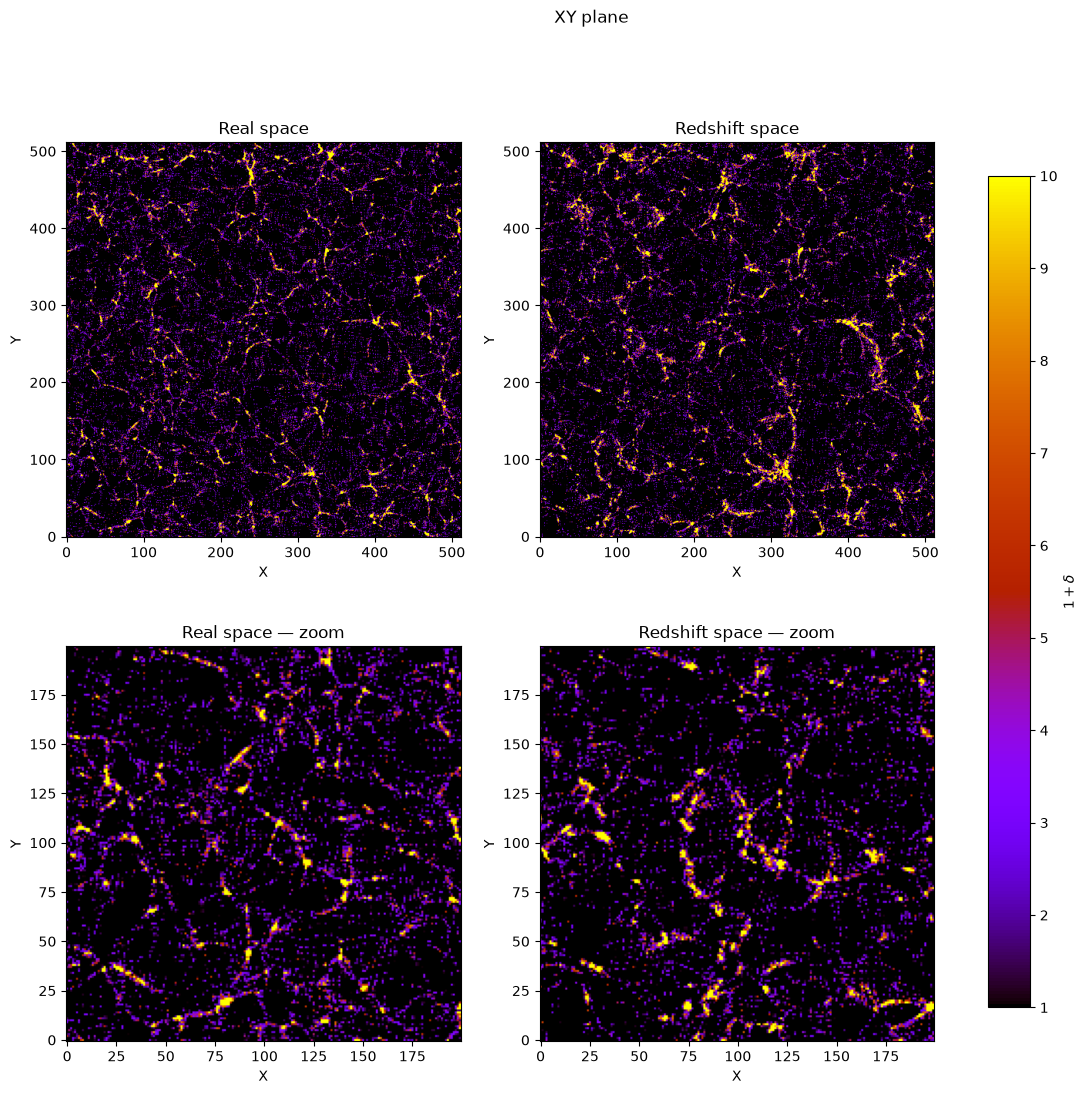

In [22]:
iz = grid//2

df_z_r = delta_r[:,:,iz] + 1
df_z_rsd = delta_rsd[:,:,iz] + 1

fig, ax = plt.subplots(2, 2, figsize=(14,12))

im = ax[0,0].imshow(df_z_r.T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')
ax[0,1].imshow(df_z_rsd.T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')

ax[1,0].imshow(df_z_r[:200,:200].T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')
ax[1,1].imshow(df_z_rsd[:200,:200].T, cmap='gnuplot', vmin=1, vmax=10, origin='lower')

ax[0,0].set_title('Real space')
ax[0,1].set_title('Redshift space')
ax[1,0].set_title('Real space — zoom')
ax[1,1].set_title('Redshift space — zoom')

ax[0,0].set_xlabel('X'); ax[0,0].set_ylabel('Y')
ax[0,1].set_xlabel('X'); ax[0,1].set_ylabel('Y')
ax[1,0].set_xlabel('X'); ax[1,0].set_ylabel('Y')
ax[1,1].set_xlabel('X'); ax[1,1].set_ylabel('Y')

cbar = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.9)
cbar.set_label(r'$1+\delta$')

fig.suptitle('XY plane')
plt.show()